✅ Data Loaded: 55392 rows, 14 columns
✅ Realistic Billing Amount Created
count     55392.00
mean      49633.28
std       17776.63
min        6241.25
25%       36077.50
50%       48967.34
75%       60937.71
max      113977.50
Name: Billing_Amount, dtype: float64
✅ Model Trained
   R² Score : 0.9871
   MAE      : $1,617.71


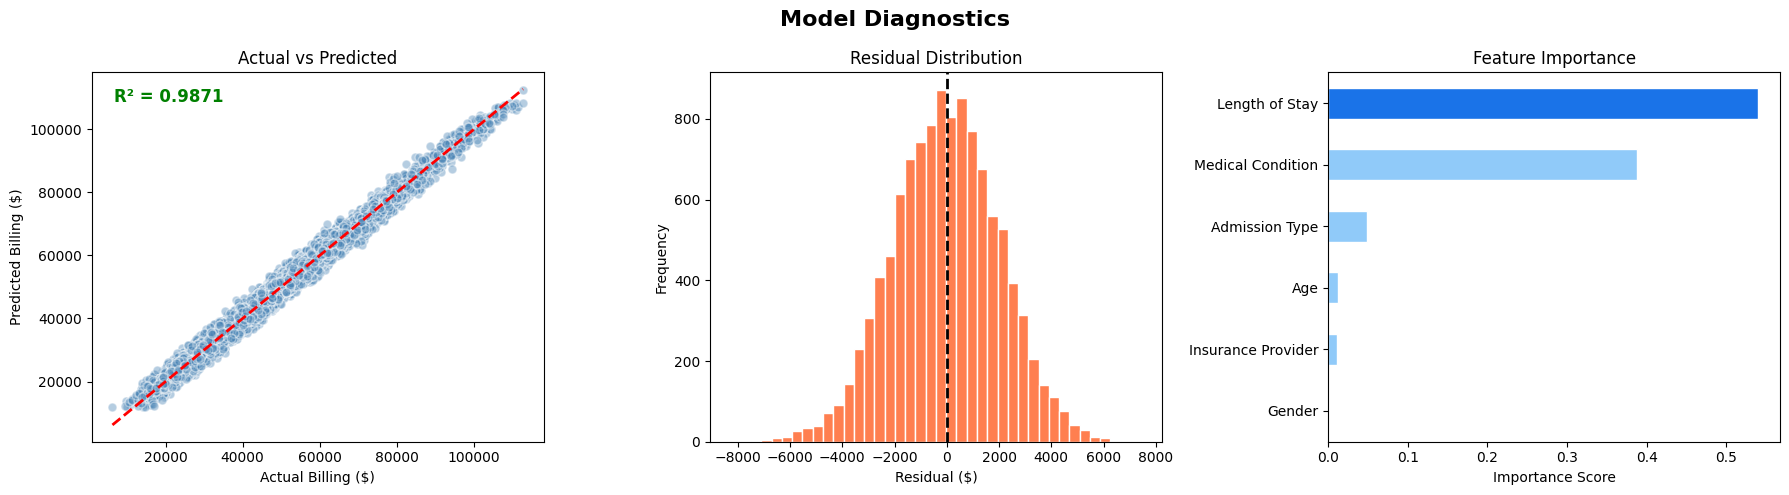

HTML(value="\n<div style='\n    padding:20px;\n    border:2px dashed #90caf9;\n    border-radius:10px;\n    te…

Overwriting score.py
Model saved!
* Running on local URL:  http://127.0.0.1:7862
* Running on public URL: https://e29aa804c142bed503.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [1]:
%run "AdvanceCode.ipynb"

In [ ]:
# Convert dates to datetime
df_original["Date_of_Admission"] = pd.to_datetime(df_original["Date_of_Admission"])
df_original["Discharge_Date"] = pd.to_datetime(df_original["Discharge_Date"])

# Create Length_of_Stay column
df_original["Length_of_Stay"] = (
    df_original["Discharge_Date"] - df_original["Date_of_Admission"]
).dt.days

# Check result
df_original[["Date_of_Admission", "Discharge_Date", "Length_of_Stay"]].head()

,Date_of_Admission,Discharge_Date,Length_of_Stay
0,2024-01-31,2024-02-02,2
1,2019-08-20,2019-08-26,6
2,2022-09-22,2022-10-07,15
3,2020-11-18,2020-12-18,30
4,2022-09-19,2022-10-09,20


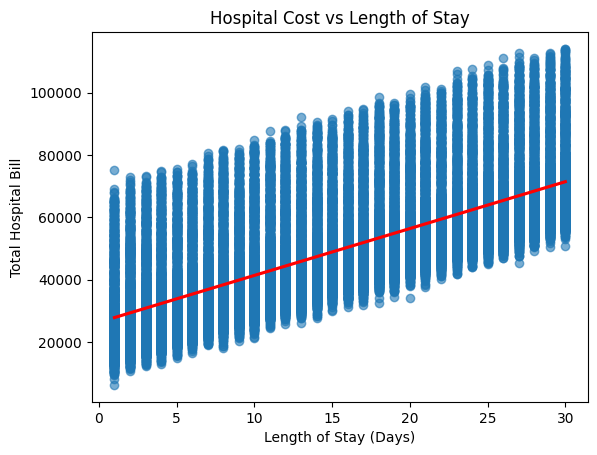

In [ ]:
plt.figure()

sns.regplot(
    x="Length_of_Stay",
    y="Billing_Amount",
    data=df2,
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"},
)

plt.title("Hospital Cost vs Length of Stay")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Total Hospital Bill")

plt.show()

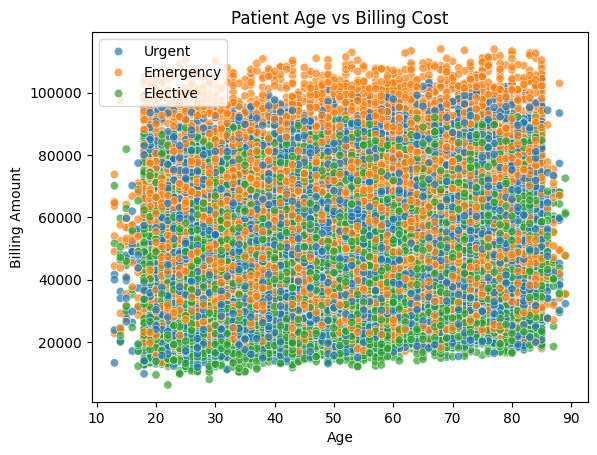

In [ ]:
plt.figure()

sns.scatterplot(x="Age", y="Billing_Amount", data=df2, hue="Admission_Type", alpha=0.7)

plt.title("Patient Age vs Billing Cost")
plt.xlabel("Age")
plt.ylabel("Billing Amount")

plt.legend()
plt.show()

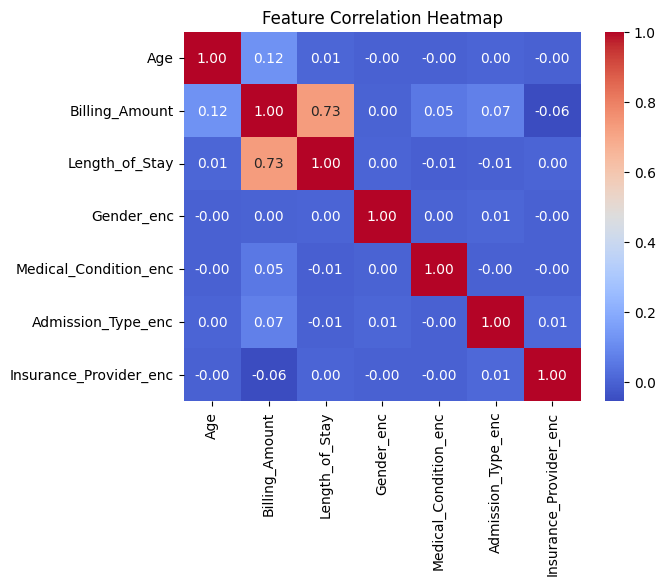

In [ ]:
plt.figure()

numeric_df = df2.select_dtypes(include=["int64", "float64"])

corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Feature Correlation Heatmap")

plt.show()

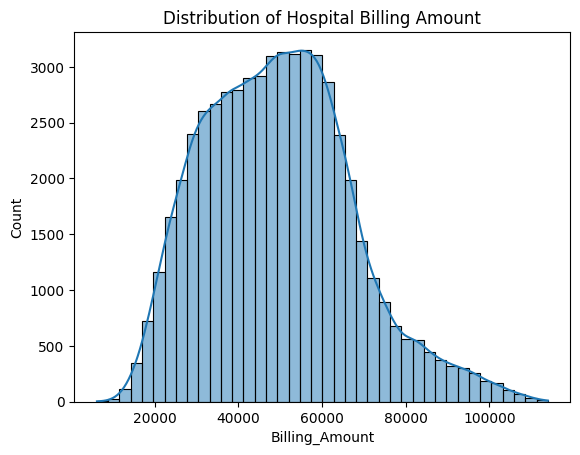

In [6]:
plt.figure()

sns.histplot(df2["Billing_Amount"], bins=40, kde=True)

plt.title("Distribution of Hospital Billing Amount")

plt.show()